<a href="https://colab.research.google.com/github/JoeyUsagi00/Tech-Challenge-Fiap/blob/main/C%C3%B3pia_de_01_data_understanding_olist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Análise base

In [ ]:
orders = pd.read_csv("olist_orders_dataset.csv")

In [ ]:
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
orders.shape

(99441, 8)

In [ ]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
orders.isnull().sum()


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
orders.duplicated().sum()


np.int64(0)

In [ ]:
orders["order_status"].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [ ]:
orders[orders["order_delivered_customer_date"].isnull()]["order_status"].value_counts()

,count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,8
created,5
approved,2


In [ ]:
orders.shape

(99441, 8)

In [ ]:
orders["order_delivered_customer_date"].isnull().sum()

np.int64(2965)

In [ ]:
customers = pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

In [ ]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Geolocation:", geolocation.shape)
print("Category Translation:", category_translation.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)
Geolocation: (1000163, 5)
Category Translation: (71, 2)


In [ ]:
print("CUSTOMERS")
print(customers.columns)

print("\nORDERS")
print(orders.columns)

print("\nORDER ITEMS")
print(order_items.columns)

print("\nPAYMENTS")
print(payments.columns)

print("\nREVIEWS")
print(reviews.columns)

print("\nPRODUCTS")
print(products.columns)

print("\nSELLERS")
print(sellers.columns)

print("\nGEOLOCATION")
print(geolocation.columns)

print("\nCATEGORY TRANSLATION")
print(category_translation.columns)

CUSTOMERS
Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

ORDERS
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

ORDER ITEMS
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

PAYMENTS
Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

REVIEWS
Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')

PRODUCTS
Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'produc

In [ ]:
orders["order_id"].nunique()

99441

In [ ]:
order_items["order_id"].nunique()


98666

In [ ]:
order_items["order_id"].value_counts().head(10)

,count
order_id,
8272b63d03f5f79c56e9e4120aec44ef,21
1b15974a0141d54e36626dca3fdc731a,20
ab14fdcfbe524636d65ee38360e22ce8,20
9ef13efd6949e4573a18964dd1bbe7f5,15
428a2f660dc84138d969ccd69a0ab6d5,15
9bdc4d4c71aa1de4606060929dee888c,14
73c8ab38f07dc94389065f7eba4f297a,14
37ee401157a3a0b28c9c6d0ed8c3b24b,13
2c2a19b5703863c908512d135aa6accc,12


In [ ]:
tabelas = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products,
    "Sellers": sellers,
    "Geolocation": geolocation,
    "Category Translation": category_translation
}

for nome, tabela in tabelas.items():
    print("\n", nome)
    print("Linhas:", tabela.shape[0])
    print("Colunas:", tabela.shape[1])
    print("Duplicados:", tabela.duplicated().sum())
    print("Nulos:", tabela.isnull().sum().sum())


 Customers
Linhas: 99441
Colunas: 5
Duplicados: 0
Nulos: 0

 Orders
Linhas: 99441
Colunas: 8
Duplicados: 0
Nulos: 4908

 Order Items
Linhas: 112650
Colunas: 7
Duplicados: 0
Nulos: 0

 Payments
Linhas: 103886
Colunas: 5
Duplicados: 0
Nulos: 0

 Reviews
Linhas: 99224
Colunas: 7
Duplicados: 0
Nulos: 145903

 Products
Linhas: 32951
Colunas: 9
Duplicados: 0
Nulos: 2448

 Sellers
Linhas: 3095
Colunas: 4
Duplicados: 0
Nulos: 0

 Geolocation
Linhas: 1000163
Colunas: 5
Duplicados: 261831
Nulos: 0

 Category Translation
Linhas: 71
Colunas: 2
Duplicados: 0
Nulos: 0


In [ ]:
orders.isnull().sum()


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [ ]:
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
orders_customers = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

In [ ]:
orders_customers.shape

(99441, 12)

In [ ]:
orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [ ]:
orders_items = orders_customers.merge(
    order_items,
    on="order_id",
    how="left"
)

In [ ]:
orders_items.shape

(113425, 18)

In [ ]:
orders_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [ ]:
orders_items["order_id"].nunique()

99441

In [ ]:
orders_items["price"].isnull().sum()

np.int64(775)

In [ ]:
orders_items[orders_items["price"].isnull()]["order_status"].value_counts()

,count
order_status,
unavailable,603
canceled,164
created,5
invoiced,2
shipped,1


In [ ]:
delivered = orders_items[
    orders_items["order_status"] == "delivered"
].copy()


# Calculo de receita

In [ ]:
delivered.shape

(110197, 18)

In [ ]:
delivered["order_id"].nunique()

96478

## Valor bruto dos pedidos

In [ ]:
gmv = delivered["price"].sum()

gmv

np.float64(13221498.110000001)

## Valor dos fretes

In [ ]:
frete = delivered["freight_value"].sum()

frete

np.float64(2198275.6399999997)

## Quantidade de pedidos entregues


In [ ]:
pedidos_entregues = delivered["order_id"].nunique()

pedidos_entregues

96478

## Cálculo do Ticket médio


In [ ]:
valor_por_pedido = (
    delivered
    .groupby("order_id")["price"]
    .sum()
)

In [ ]:
ticket_medio = valor_por_pedido.mean()

ticket_medio

np.float64(137.0415857501192)

In [ ]:
delivered.shape

(110197, 18)

In [ ]:
delivered["order_id"].nunique()

96478

In [ ]:
gmv

np.float64(13221498.110000001)

In [ ]:
frete

np.float64(2198275.6399999997)

In [ ]:
pedidos_entregues

96478

In [ ]:
ticket_medio

np.float64(137.0415857501192)

# Analise evolução 2017 para 2018


In [ ]:
delivered["order_purchase_timestamp"] = pd.to_datetime(
    delivered["order_purchase_timestamp"]
)

In [ ]:
delivered["mes"] = delivered["order_purchase_timestamp"].dt.to_period("M")

In [ ]:
mensal = (
    delivered
    .groupby("mes")
    .agg(
        pedidos=("order_id", "nunique"),
        gmv=("price", "sum")
    )
    .reset_index()
)

mensal

,mes,pedidos,gmv
0,2016-09,1,134.97
1,2016-10,265,40325.11
2,2016-12,1,10.90
3,2017-01,750,111798.36
4,2017-02,1653,234223.40
5,2017-03,2546,359198.85
6,2017-04,2303,340669.68
7,2017-05,3546,489338.25
8,2017-06,3135,421923.37
9,2017-07,3872,481604.52


In [ ]:
mensal["mes"] = mensal["mes"].astype(str)

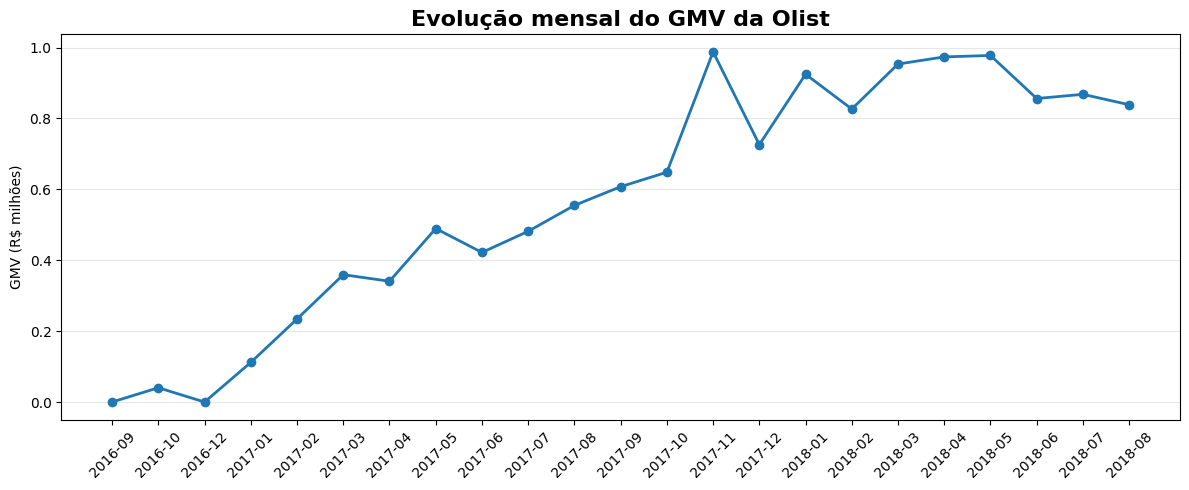

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    mensal["mes"],
    mensal["gmv"] / 1_000_000,
    marker="o",
    linewidth=2
)

plt.title(
    "Evolução mensal do GMV da Olist",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("GMV (R$ milhões)")
plt.xlabel("")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
gmv_2017 = mensal[
    mensal["mes"].between("2017-01", "2017-08")
]["gmv"].sum()

gmv_2018 = mensal[
    mensal["mes"].between("2018-01", "2018-08")
]["gmv"].sum()

crescimento_gmv = (gmv_2018 / gmv_2017 - 1) * 100

print("GMV Jan-Ago/2017:", gmv_2017)
print("GMV Jan-Ago/2018:", gmv_2018)
print("Crescimento:", crescimento_gmv)

GMV Jan-Ago/2017: 2993456.13
GMV Jan-Ago/2018: 7218125.12
Crescimento: 141.13014544161703


In [ ]:
pedidos_2017 = mensal[
    mensal["mes"].between("2017-01", "2017-08")
]["pedidos"].sum()

pedidos_2018 = mensal[
    mensal["mes"].between("2018-01", "2018-08")
]["pedidos"].sum()

crescimento_pedidos = (pedidos_2018 / pedidos_2017 - 1) * 100

ticket_2017 = gmv_2017 / pedidos_2017
ticket_2018 = gmv_2018 / pedidos_2018

print("Pedidos Jan-Ago/2017:", pedidos_2017)
print("Pedidos Jan-Ago/2018:", pedidos_2018)
print("Crescimento dos pedidos:", crescimento_pedidos)
print("Ticket médio 2017:", ticket_2017)
print("Ticket médio 2018:", ticket_2018)

Pedidos Jan-Ago/2017: 21998
Pedidos Jan-Ago/2018: 52783
Crescimento dos pedidos: 139.94454041276478
Ticket médio 2017: 136.07855850531865
Ticket médio 2018: 136.75094481177652


# Análise da Logística

In [ ]:
delivered["order_delivered_customer_date"] = pd.to_datetime(
    delivered["order_delivered_customer_date"]
)

delivered["order_estimated_delivery_date"] = pd.to_datetime(
    delivered["order_estimated_delivery_date"]
)

In [ ]:
delivered["tempo_entrega"] = (
    delivered["order_delivered_customer_date"]
    - delivered["order_purchase_timestamp"]
).dt.days

In [ ]:
delivered["dias_atraso"] = (
    delivered["order_delivered_customer_date"]
    - delivered["order_estimated_delivery_date"]
).dt.days

In [ ]:
delivered["atrasado"] = delivered["dias_atraso"] > 0

In [ ]:
print("Tempo médio de entrega:", delivered["tempo_entrega"].mean())

print(
    "Taxa de atraso:",
    delivered["atrasado"].mean() * 100
)

Tempo médio de entrega: 12.007341930682736
Taxa de atraso: 6.591830993584217


In [ ]:
pedidos_logistica = (
    delivered
    .drop_duplicates(subset="order_id")
    .copy()
)

In [ ]:
print(
    "Tempo médio de entrega:",
    pedidos_logistica["tempo_entrega"].mean()
)

print(
    "Taxa de atraso:",
    pedidos_logistica["atrasado"].mean() * 100
)

Tempo médio de entrega: 12.093604229294082
Taxa de atraso: 6.77252845208234


# Analise entre atraso na entrega e reviews

In [ ]:
pedidos_reviews = pedidos_logistica.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

In [ ]:
print("Linhas:", pedidos_reviews.shape[0])
print("Pedidos únicos:", pedidos_reviews["order_id"].nunique())
print("Reviews nulos:", pedidos_reviews["review_score"].isnull().sum())

Linhas: 97007
Pedidos únicos: 96478
Reviews nulos: 646


In [ ]:
reviews["order_id"].duplicated().sum()

np.int64(551)

In [ ]:
reviews["order_id"].value_counts().head(10)

,count
order_id,
03c939fd7fd3b38f8485a0f95798f1f6,3
8e17072ec97ce29f0e1f111e598b0c85,3
c88b1d1b157a9999ce368f218a407141,3
df56136b8031ecd28e200bb18e6ddb2e,3
843be4a0dcdb9716de7652d53af4acab,2
03eba6d9fef8f5b3e811d4b5a7cca9cd,2
c0db7d31ace61fc360a3eaa34dd3457c,2
ceb533871105f7cda81fafc19e1ee38e,2
77ef3216467887c78ddec18de86a58b9,2


In [ ]:
reviews[reviews["order_id"].duplicated(keep=False)].sort_values("order_id").head(20)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:06
83224,d8e8c42271c8fb67b9dad95d98c8ff80,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:47
17582,017f0e1ea6386de662cbeba299c59ad1,02355020fd0a40a0d56df9f6ff060413,1,NaN,ja reclamei varias vezes e ate hoje não sei on...,2018-03-29 00:00:00,2018-03-30 03:16:19
89888,0c8e7347f1cdd2aede37371543e3d163,02355020fd0a40a0d56df9f6ff060413,3,NaN,UM DOS PRODUTOS (ENTREGA02) COMPRADOS NESTE PE...,2018-03-21 00:00:00,2018-03-22 01:32:08
55137,61fe4e7d1ae801bbe169eb67b86c6eda,029863af4b968de1e5d6a82782e662f5,4,NaN,NaN,2017-07-19 00:00:00,2017-07-20 12:06:11
37911,04d945e95c788a3aa1ffbee42105637b,029863af4b968de1e5d6a82782e662f5,5,NaN,NaN,2017-07-14 00:00:00,2017-07-17 13:58:06


## Seleção dos timestamp mais recente para os reviwes duplicados

In [ ]:
reviews["review_answer_timestamp"] = pd.to_datetime(
    reviews["review_answer_timestamp"]
)

In [ ]:
reviews_ordenadas = reviews.sort_values(
    "review_answer_timestamp"
)

In [ ]:
reviews_ultima = reviews_ordenadas.drop_duplicates(
    subset="order_id",
    keep="last"
)

In [ ]:
print("Linhas:", reviews_ultima.shape[0])
print("Pedidos únicos:", reviews_ultima["order_id"].nunique())
print("Duplicados:", reviews_ultima["order_id"].duplicated().sum())

Linhas: 98673
Pedidos únicos: 98673
Duplicados: 0


In [ ]:
pedidos_reviews = pedidos_logistica.merge(
    reviews_ultima[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

In [ ]:
print("Linhas:", pedidos_reviews.shape[0])
print("Pedidos únicos:", pedidos_reviews["order_id"].nunique())
print("Sem avaliação:", pedidos_reviews["review_score"].isnull().sum())

Linhas: 96478
Pedidos únicos: 96478
Sem avaliação: 646


In [ ]:
pedidos_reviews.groupby("atrasado")["review_score"].agg(
    ["count", "mean"]
)

,count,mean
atrasado,,
False,89451,4.290405
True,6381,2.270491


In [ ]:
def faixa_atraso(dias):
    if dias <= 0:
        return "No prazo"
    elif dias <= 3:
        return "1 a 3 dias"
    elif dias <= 7:
        return "4 a 7 dias"
    elif dias <= 14:
        return "8 a 14 dias"
    else:
        return "15+ dias"

In [ ]:
pedidos_reviews["faixa_atraso"] = (
    pedidos_reviews["dias_atraso"].apply(faixa_atraso)
)

# Atraso x Satisfação

In [ ]:
ordem_faixas = [
    "No prazo",
    "1 a 3 dias",
    "4 a 7 dias",
    "8 a 14 dias",
    "15+ dias"
]

analise_atraso = (
    pedidos_reviews
    .groupby("faixa_atraso")["review_score"]
    .agg(["count", "mean"])
    .reindex(ordem_faixas)
)

analise_atraso

,count,mean
faixa_atraso,,
No prazo,89443,4.290386
1 a 3 dias,1852,3.291037
4 a 7 dias,1748,2.102975
8 a 14 dias,1446,1.670816
15+ dias,1343,1.740134


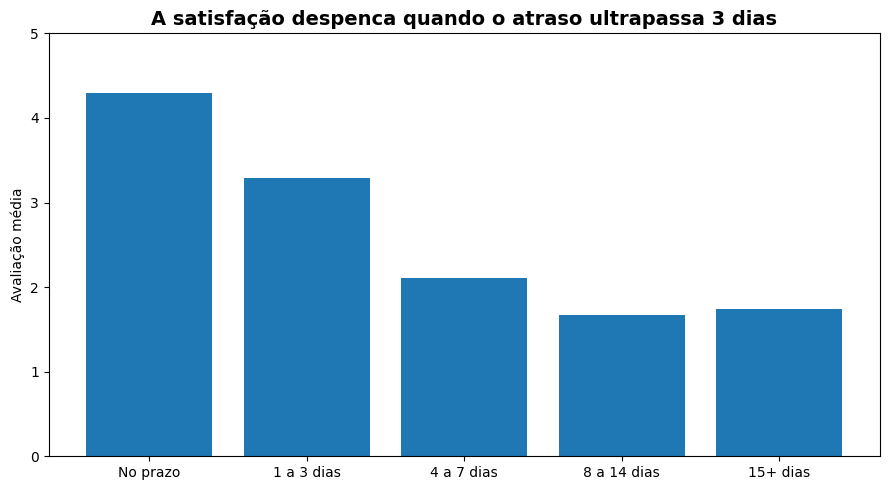

In [ ]:
grafico_atraso = analise_atraso.reset_index()

plt.figure(figsize=(9, 5))

plt.bar(
    grafico_atraso["faixa_atraso"],
    grafico_atraso["mean"]
)

plt.title(
    "A satisfação despenca quando o atraso ultrapassa 3 dias",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Avaliação média")
plt.xlabel("")

plt.ylim(0, 5)

plt.tight_layout()
plt.show()

<BarContainer object of 5 artists>

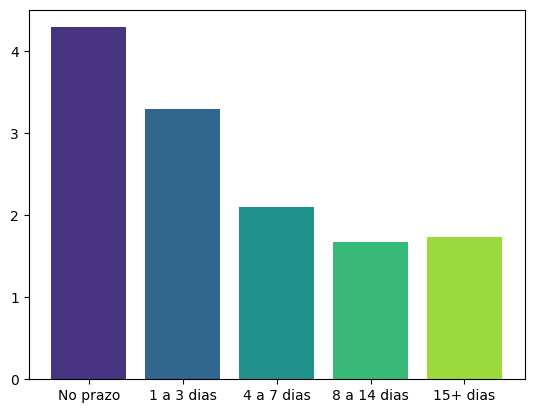

In [ ]:
cores = plt.cm.viridis(np.linspace(0.15, 0.85, len(grafico_atraso)))

plt.bar(
    grafico_atraso["faixa_atraso"],
    grafico_atraso["mean"],
    color=cores
)

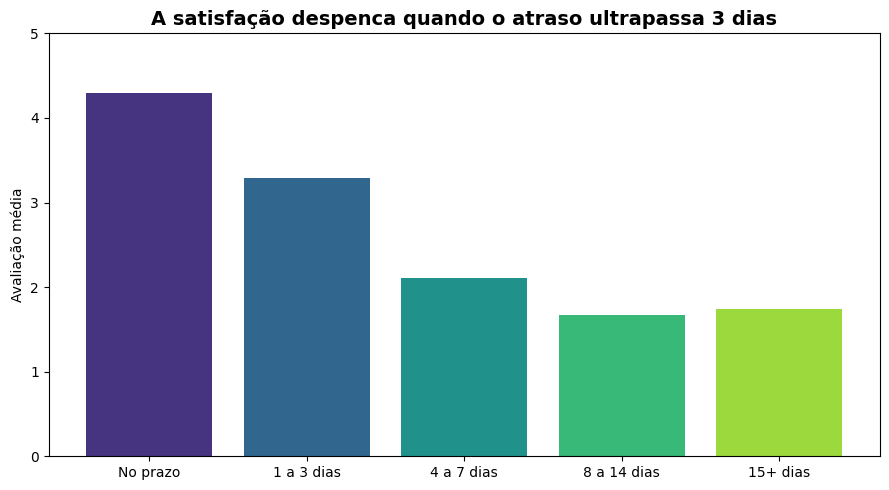

In [ ]:
grafico_atraso = analise_atraso.reset_index()

plt.figure(figsize=(9, 5))

cores = plt.cm.viridis(
    np.linspace(0.15, 0.85, len(grafico_atraso))
)

plt.bar(
    grafico_atraso["faixa_atraso"],
    grafico_atraso["mean"],
    color=cores
)

plt.title(
    "A satisfação despenca quando o atraso ultrapassa 3 dias",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Avaliação média")
plt.xlabel("")

plt.ylim(0, 5)

plt.tight_layout()
plt.show()


# Análise por estado

In [ ]:
analise_estado = (
    pedidos_reviews
    .groupby("customer_state")
    .agg(
        pedidos=("order_id", "nunique"),
        tempo_medio_entrega=("tempo_entrega", "mean"),
        taxa_atraso=("atrasado", "mean"),
        review_medio=("review_score", "mean")
    )
    .reset_index()
)

analise_estado["taxa_atraso"] = analise_estado["taxa_atraso"] * 100

analise_estado

,customer_state,pedidos,tempo_medio_entrega,taxa_atraso,review_medio
0,AC,80,20.637500,3.750000,4.087500
1,AL,397,24.040302,21.410579,3.847716
2,AM,145,25.986207,2.758621,4.243056
3,AP,67,26.731343,2.985075,4.242424
4,BA,3256,18.866400,12.162162,3.930629
5,CE,1279,20.817826,13.760751,3.944226
6,DF,2080,12.509135,5.673077,4.131401
7,ES,1995,15.331830,10.726817,4.078720
8,GO,1957,15.150741,6.540623,4.105858
9,MA,717,21.117155,17.433752,3.832865


In [ ]:
analise_estado.sort_values(
    "taxa_atraso",
    ascending=False
)

,customer_state,pedidos,tempo_medio_entrega,taxa_atraso,review_medio
1,AL,397,24.040302,21.410579,3.847716
9,MA,717,21.117155,17.433752,3.832865
24,SE,335,21.029851,15.223881,3.907186
16,PI,476,18.993697,13.865546,3.993631
5,CE,1279,20.817826,13.760751,3.944226
21,RR,41,28.975610,12.195122,3.902439
4,BA,3256,18.866400,12.162162,3.930629
18,RJ,12350,14.848583,12.105263,3.965441
13,PA,946,23.316068,11.205074,3.914255
7,ES,1995,15.331830,10.726817,4.078720


## Analise volume pedidos e review

In [ ]:
analise_estado.sort_values(
    "pedidos",
    ascending=False
).head(10)

,customer_state,pedidos,tempo_medio_entrega,taxa_atraso,review_medio
25,SP,40501,8.298094,4.493716,4.245822
18,RJ,12350,14.848583,12.105263,3.965441
10,MG,11354,11.542188,4.571076,4.192291
22,RS,5345,14.819237,6.080449,4.184907
17,PR,4923,11.526711,4.042251,4.239796
23,SC,3546,14.475183,8.206430,4.133561
4,BA,3256,18.866400,12.162162,3.930629
6,DF,2080,12.509135,5.673077,4.131401
7,ES,1995,15.331830,10.726817,4.078720
8,GO,1957,15.150741,6.540623,4.105858


In [ ]:
gmv_estado = (
    delivered
    .groupby("customer_state")["price"]
    .sum()
    .reset_index(name="gmv")
)

In [ ]:
analise_estado = analise_estado.merge(
    gmv_estado,
    on="customer_state",
    how="left"
)

## GMV por UF e review

In [ ]:
analise_estado.sort_values(
    "gmv",
    ascending=False
).head(10)

,customer_state,pedidos,tempo_medio_entrega,taxa_atraso,review_medio,gmv
25,SP,40501,8.298094,4.493716,4.245822,5067633.16
18,RJ,12350,14.848583,12.105263,3.965441,1759651.13
10,MG,11354,11.542188,4.571076,4.192291,1552481.83
22,RS,5345,14.819237,6.080449,4.184907,728897.47
17,PR,4923,11.526711,4.042251,4.239796,666063.51
23,SC,3546,14.475183,8.206430,4.133561,507012.13
4,BA,3256,18.866400,12.162162,3.930629,493584.14
6,DF,2080,12.509135,5.673077,4.131401,296498.41
8,GO,1957,15.150741,6.540623,4.105858,282836.70
7,ES,1995,15.331830,10.726817,4.078720,268643.45


In [ ]:
analise_estado["pedidos_atrasados"] = (
    analise_estado["pedidos"] *
    analise_estado["taxa_atraso"] / 100
)

In [ ]:
analise_estado.sort_values(
    "pedidos_atrasados",
    ascending=False
)[[
    "customer_state",
    "pedidos",
    "taxa_atraso",
    "pedidos_atrasados",
    "review_medio",
    "gmv"
]].head(10)

,customer_state,pedidos,taxa_atraso,pedidos_atrasados,review_medio,gmv
25,SP,40501,4.493716,1820.0,4.245822,5067633.16
18,RJ,12350,12.105263,1495.0,3.965441,1759651.13
10,MG,11354,4.571076,519.0,4.192291,1552481.83
4,BA,3256,12.162162,396.0,3.930629,493584.14
22,RS,5345,6.080449,325.0,4.184907,728897.47
23,SC,3546,8.206430,291.0,4.133561,507012.13
7,ES,1995,10.726817,214.0,4.078720,268643.45
17,PR,4923,4.042251,199.0,4.239796,666063.51
5,CE,1279,13.760751,176.0,3.944226,219757.38
15,PE,1593,9.604520,153.0,4.082964,251889.49


In [ ]:
analise_estado["gmv_exposto"] = (
    analise_estado["gmv"] *
    analise_estado["taxa_atraso"] / 100
)

In [ ]:
analise_estado.sort_values(
    "gmv_exposto",
    ascending=False
)[[
    "customer_state",
    "gmv",
    "taxa_atraso",
    "gmv_exposto",
    "review_medio"
]].head(10)

,customer_state,gmv,taxa_atraso,gmv_exposto,review_medio
25,SP,5067633.16,4.493716,227725.052497,4.245822
18,RJ,1759651.13,12.105263,213010.399947,3.965441
10,MG,1552481.83,4.571076,70965.128569,4.192291
4,BA,493584.14,12.162162,60030.503514,3.930629
22,RS,728897.47,6.080449,44320.239055,4.184907
23,SC,507012.13,8.206430,41607.594425,4.133561
5,CE,219757.38,13.760751,30240.264957,3.944226
7,ES,268643.45,10.726817,28816.891378,4.078720
17,PR,666063.51,4.042251,26923.956630,4.239796
15,PE,251889.49,9.604520,24192.775876,4.082964


In [ ]:
gmv_atrasado_estado = (
    delivered[delivered["atrasado"] == True]
    .groupby("customer_state")["price"]
    .sum()
    .reset_index(name="gmv_atrasado")
)

In [ ]:
analise_estado = analise_estado.merge(
    gmv_atrasado_estado,
    on="customer_state",
    how="left"
)

In [ ]:
analise_estado["percentual_gmv_atrasado"] = (
    analise_estado["gmv_atrasado"] /
    analise_estado["gmv"]
) * 100

In [ ]:
analise_estado.columns

Index(['customer_state', 'pedidos', 'tempo_medio_entrega', 'taxa_atraso',
       'review_medio', 'gmv', 'pedidos_atrasados', 'gmv_exposto',
       'gmv_atrasado', 'percentual_gmv_atrasado'],
      dtype='object')

In [ ]:
gmv_atrasado_estado = (
    delivered[delivered["atrasado"] == True]
    .groupby("customer_state")["price"]
    .sum()
    .reset_index(name="gmv_atrasado")
)

In [ ]:
gmv_atrasado_estado.head()

,customer_state,gmv_atrasado
0,AC,1524.99
1,AL,18083.67
2,AM,676.78
3,AP,270.80
4,BA,62058.74


In [ ]:
analise_estado = analise_estado.drop(
    columns=["gmv_atrasado", "gmv_atrasado_x", "gmv_atrasado_y"],
    errors="ignore"
)

In [ ]:
analise_estado = analise_estado.merge(
    gmv_atrasado_estado,
    on="customer_state",
    how="left"
)

In [ ]:
analise_estado.columns

Index(['customer_state', 'pedidos', 'tempo_medio_entrega', 'taxa_atraso',
       'review_medio', 'gmv', 'pedidos_atrasados', 'gmv_exposto',
       'percentual_gmv_atrasado', 'gmv_atrasado'],
      dtype='object')

In [ ]:
analise_estado["percentual_gmv_atrasado"] = (
    analise_estado["gmv_atrasado"] /
    analise_estado["gmv"]
) * 100

In [ ]:
analise_estado.sort_values(
    "gmv_atrasado",
    ascending=False
)[[
    "customer_state",
    "pedidos",
    "taxa_atraso",
    "pedidos_atrasados",
    "gmv",
    "gmv_atrasado",
    "percentual_gmv_atrasado",
    "review_medio"
]].head(10)

,customer_state,pedidos,taxa_atraso,pedidos_atrasados,gmv,gmv_atrasado,percentual_gmv_atrasado,review_medio
25,SP,40501,4.493716,1820.0,5067633.16,269383.42,5.315764,4.245822
18,RJ,12350,12.105263,1495.0,1759651.13,215415.46,12.241941,3.965441
10,MG,11354,4.571076,519.0,1552481.83,75837.49,4.884920,4.192291
4,BA,3256,12.162162,396.0,493584.14,62058.74,12.573082,3.930629
22,RS,5345,6.080449,325.0,728897.47,43968.03,6.032128,4.184907
23,SC,3546,8.206430,291.0,507012.13,38103.95,7.515392,4.133561
7,ES,1995,10.726817,214.0,268643.45,34907.68,12.994056,4.078720
5,CE,1279,13.760751,176.0,219757.38,30604.18,13.926349,3.944226
17,PR,4923,4.042251,199.0,666063.51,29504.05,4.429615,4.239796
15,PE,1593,9.604520,153.0,251889.49,26746.30,10.618268,4.082964


# Análise Categorias

In [ ]:
delivered_produtos = delivered.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

In [ ]:
delivered_produtos = delivered_produtos.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

In [ ]:
print("Linhas:", delivered_produtos.shape[0])
print("Pedidos:", delivered_produtos["order_id"].nunique())
print(
    "Categorias sem identificação:",
    delivered_produtos["product_category_name"].isnull().sum()
)

Linhas: 110197
Pedidos: 96478
Categorias sem identificação: 1537


In [ ]:
delivered_produtos["categoria"] = (
    delivered_produtos["product_category_name_english"]
    .fillna("Sem categoria")
)

In [ ]:
categoria_financeiro = (
    delivered_produtos
    .groupby("categoria")
    .agg(
        gmv=("price", "sum"),
        pedidos=("order_id", "nunique"),
        itens=("order_id", "count")
    )
    .reset_index()
)

In [ ]:
categoria_financeiro["ticket_medio"] = (
    categoria_financeiro["gmv"] /
    categoria_financeiro["pedidos"]
)

categoria_financeiro["participacao_gmv"] = (
    categoria_financeiro["gmv"] /
    categoria_financeiro["gmv"].sum() * 100
)

In [ ]:
categoria_financeiro.sort_values(
    "gmv",
    ascending=False
).head(15)

,categoria,gmv,pedidos,itens,ticket_medio,participacao_gmv
44,health_beauty,1233131.72,8647,9465,142.608040,9.326717
71,watches_gifts,1166176.98,5495,5859,212.225110,8.820309
8,bed_bath_table,1023434.76,9272,10953,110.379072,7.740687
66,sports_leisure,954852.55,7530,8431,126.806448,7.221969
16,computers_accessories,888724.61,6530,7644,136.098715,6.721815
40,furniture_decor,711927.69,6307,8160,112.878974,5.384622
50,housewares,615628.69,5743,6795,107.196359,4.656270
21,cool_stuff,610204.10,3559,3718,171.453807,4.615242
6,auto,578966.65,3810,4140,151.959751,4.378979
70,toys,471286.48,3804,4030,123.892345,3.564547


In [ ]:
pedido_categoria = (
    delivered_produtos[
        ["order_id", "categoria"]
    ]
    .drop_duplicates()
)

In [ ]:
pedido_categoria = pedido_categoria.merge(
    pedidos_reviews[
        ["order_id", "atrasado", "tempo_entrega", "review_score"]
    ],
    on="order_id",
    how="left"
)

In [ ]:
categoria_experiencia = (
    pedido_categoria
    .groupby("categoria")
    .agg(
        taxa_atraso=("atrasado", "mean"),
        tempo_medio_entrega=("tempo_entrega", "mean"),
        review_medio=("review_score", "mean")
    )
    .reset_index()
)

categoria_experiencia["taxa_atraso"] *= 100

In [ ]:
analise_categoria = categoria_financeiro.merge(
    categoria_experiencia,
    on="categoria",
    how="left"
)

In [ ]:
analise_categoria.sort_values(
    "gmv",
    ascending=False
).head(15)

,categoria,gmv,pedidos,itens,ticket_medio,participacao_gmv,taxa_atraso,tempo_medio_entrega,review_medio
44,health_beauty,1233131.72,8647,9465,142.608040,9.326717,7.505493,11.612582,4.229276
71,watches_gifts,1166176.98,5495,5859,212.225110,8.820309,7.388535,12.333879,4.121195
8,bed_bath_table,1023434.76,9272,10953,110.379072,7.740687,7.430975,12.519845,3.998910
66,sports_leisure,954852.55,7530,8431,126.806448,7.221969,6.573705,11.778988,4.227491
16,computers_accessories,888724.61,6530,7644,136.098715,6.721815,6.385911,12.725379,4.081089
40,furniture_decor,711927.69,6307,8160,112.878974,5.384622,7.119074,12.600444,4.057508
50,housewares,615628.69,5743,6795,107.196359,4.656270,5.363051,10.623368,4.193029
21,cool_stuff,610204.10,3559,3718,171.453807,4.615242,5.900534,11.917112,4.217502
6,auto,578966.65,3810,4140,151.959751,4.378979,7.296588,11.872145,4.145306
70,toys,471286.48,3804,4030,123.892345,3.564547,6.388013,11.262161,4.237679


In [ ]:
mediana_gmv = analise_categoria["gmv"].median()
mediana_review = analise_categoria["review_medio"].median()

print("Mediana GMV:", mediana_gmv)
print("Mediana Review:", mediana_review)

Mediana GMV: 46060.770000000004
Mediana Review: 4.176153746714354


In [ ]:
def classificar_categoria(row):
    if row["gmv"] >= mediana_gmv and row["review_medio"] >= mediana_review:
        return "ACELERAR"

    elif row["gmv"] >= mediana_gmv and row["review_medio"] < mediana_review:
        return "CORRIGIR"

    elif row["gmv"] < mediana_gmv and row["review_medio"] >= mediana_review:
        return "DESENVOLVER"

    else:
        return "REAVALIAR"

In [ ]:
analise_categoria["estrategia"] = analise_categoria.apply(
    classificar_categoria,
    axis=1
)

In [ ]:
analise_categoria.sort_values(
    "gmv",
    ascending=False
)[[
    "categoria",
    "gmv",
    "review_medio",
    "taxa_atraso",
    "estrategia"
]].head(20)

,categoria,gmv,review_medio,taxa_atraso,estrategia
44,health_beauty,1233131.72,4.229276,7.505493,ACELERAR
71,watches_gifts,1166176.98,4.121195,7.388535,CORRIGIR
8,bed_bath_table,1023434.76,3.998910,7.430975,CORRIGIR
66,sports_leisure,954852.55,4.227491,6.573705,ACELERAR
16,computers_accessories,888724.61,4.081089,6.385911,CORRIGIR
40,furniture_decor,711927.69,4.057508,7.119074,CORRIGIR
50,housewares,615628.69,4.193029,5.363051,ACELERAR
21,cool_stuff,610204.10,4.217502,5.900534,ACELERAR
6,auto,578966.65,4.145306,7.296588,CORRIGIR
70,toys,471286.48,4.237679,6.388013,ACELERAR


## Analise peso dos produtos

In [ ]:
products["volume_cm3"] = (
    products["product_length_cm"] *
    products["product_height_cm"] *
    products["product_width_cm"]
)

In [ ]:
delivered_produtos.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'mes',
 'tempo_entrega',
 'dias_atraso',
 'atrasado',
 'product_category_name',
 'product_category_name_english',
 'categoria']

In [ ]:
products["volume_cm3"] = (
    products["product_length_cm"] *
    products["product_height_cm"] *
    products["product_width_cm"]
)

In [ ]:
delivered_produtos = delivered_produtos.merge(
    products[
        ["product_id", "product_weight_g", "volume_cm3"]
    ],
    on="product_id",
    how="left"
)

In [ ]:
print("Linhas:", delivered_produtos.shape[0])
print("Pedidos:", delivered_produtos["order_id"].nunique())

Linhas: 110197
Pedidos: 96478


In [ ]:
fisico_categoria = (
    delivered_produtos
    .groupby("categoria")
    .agg(
        peso_medio_g=("product_weight_g", "mean"),
        volume_medio_cm3=("volume_cm3", "mean")
    )
    .reset_index()
)

In [ ]:
analise_categoria = analise_categoria.merge(
    fisico_categoria,
    on="categoria",
    how="left"
)

In [ ]:
analise_categoria.sort_values(
    "gmv",
    ascending=False
)[[
    "categoria",
    "gmv",
    "peso_medio_g",
    "volume_medio_cm3",
    "tempo_medio_entrega",
    "taxa_atraso",
    "review_medio"
]].head(20)

,categoria,gmv,peso_medio_g,volume_medio_cm3,tempo_medio_entrega,taxa_atraso,review_medio
44,health_beauty,1233131.72,1047.383518,8276.452509,11.612582,7.505493,4.229276
71,watches_gifts,1166176.98,584.067588,2851.821471,12.333879,7.388535,4.121195
8,bed_bath_table,1023434.76,2118.636355,16611.322743,12.519845,7.430975,3.998910
66,sports_leisure,954852.55,1706.403985,13371.630530,11.778988,6.573705,4.227491
16,computers_accessories,888724.61,898.372449,5520.005756,12.725379,6.385911,4.081089
40,furniture_decor,711927.69,2640.267157,19415.276838,12.600444,7.119074,4.057508
50,housewares,615628.69,3216.652686,22707.176306,10.623368,5.363051,4.193029
21,cool_stuff,610204.10,2543.946208,21113.353147,11.917112,5.900534,4.217502
6,auto,578966.65,2596.103865,18092.440338,11.872145,7.296588,4.145306
70,toys,471286.48,1853.013151,18919.193548,11.262161,6.388013,4.237679


In [ ]:
analise_categoria[[
    "peso_medio_g",
    "volume_medio_cm3",
    "tempo_medio_entrega",
    "taxa_atraso",
    "review_medio"
]].corr()

,peso_medio_g,volume_medio_cm3,tempo_medio_entrega,taxa_atraso,review_medio
peso_medio_g,1.000000,0.937195,0.311259,0.176139,-0.087884
volume_medio_cm3,0.937195,1.000000,0.338873,0.238844,-0.140128
tempo_medio_entrega,0.311259,0.338873,1.000000,0.468449,-0.516418
taxa_atraso,0.176139,0.238844,0.468449,1.000000,-0.130305
review_medio,-0.087884,-0.140128,-0.516418,-0.130305,1.000000


# Retenção de clientes

In [ ]:
clientes_unicos = pedidos_logistica["customer_unique_id"].nunique()

print("Clientes únicos:", clientes_unicos)

Clientes únicos: 93358


In [ ]:
pedidos_por_cliente = (
    pedidos_logistica
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index(name="numero_pedidos")
)

pedidos_por_cliente.head()

,customer_unique_id,numero_pedidos
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [ ]:
clientes_recorrentes = (
    pedidos_por_cliente["numero_pedidos"] > 1
).sum()

taxa_recorrencia = (
    clientes_recorrentes /
    clientes_unicos * 100
)

print("Clientes únicos:", clientes_unicos)
print("Clientes recorrentes:", clientes_recorrentes)
print("Recorrência observada:", taxa_recorrencia)

Clientes únicos: 93358
Clientes recorrentes: 2801
Recorrência observada: 3.0002784978255748


In [ ]:
pedidos_por_cliente["numero_pedidos"].value_counts().sort_index()

,count
numero_pedidos,
1,90557
2,2573
3,181
4,28
5,9
6,5
7,3
9,1
15,1


In [ ]:
pedidos_por_cliente.sort_values(
    "numero_pedidos",
    ascending=False
).head(10)

,customer_unique_id,numero_pedidos
51431,8d50f5eadf50201ccdcedfb9e2ac8455,15
22779,3e43e6105506432c953e165fb2acf44c,9
36706,6469f99c1f9dfae7733b25662e7f1782,7
73921,ca77025e7201e3b30c44b472ff346268,7
10060,1b6c7548a2a1f9037c1fd3ddfed95f33,7
87885,f0e310a6839dce9de1638e0fe5ab282a,6
26257,47c1a3033b8b77b3ab6e109eb4d5fdf3,6
6964,12f5d6e1cbf93dafd9dcc19095df0b3d,6
36500,63cfc61cee11cbe306bff5857d00bfe4,6
80538,dc813062e0fc23409cd255f7f53c7074,6


In [ ]:
clientes_unicos = pedidos_por_cliente["customer_unique_id"].nunique()

clientes_recorrentes = (
    pedidos_por_cliente["numero_pedidos"] > 1
).sum()

taxa_recorrencia = (
    clientes_recorrentes / clientes_unicos
) * 100

print("Clientes únicos:", clientes_unicos)
print("Clientes recorrentes:", clientes_recorrentes)
print("Recorrência observada:", taxa_recorrencia)

Clientes únicos: 93358
Clientes recorrentes: 2801
Recorrência observada: 3.0002784978255748


In [ ]:
pedidos_cliente = pedidos_reviews.sort_values(
    ["customer_unique_id", "order_purchase_timestamp"]
).copy()

In [ ]:
primeira_compra = (
    pedidos_cliente
    .groupby("customer_unique_id")
    .first()
    .reset_index()
)

In [ ]:
primeira_compra = primeira_compra.merge(
    pedidos_por_cliente,
    on="customer_unique_id",
    how="left"
)

primeira_compra["recomprou"] = (
    primeira_compra["numero_pedidos"] > 1
)

In [ ]:
def classificar_review(nota):
    if nota <= 2:
        return "Ruim (1-2)"
    elif nota == 3:
        return "Neutra (3)"
    else:
        return "Boa (4-5)"

primeira_compra["experiencia_inicial"] = (
    primeira_compra["review_score"].apply(classificar_review)
)

In [ ]:
recompra_review = (
    primeira_compra
    .groupby("experiencia_inicial")
    .agg(
        clientes=("customer_unique_id", "nunique"),
        taxa_recompra=("recomprou", "mean")
    )
    .reset_index()
)

recompra_review["taxa_recompra"] *= 100

recompra_review

,experiencia_inicial,clientes,taxa_recompra
0,Boa (4-5),73771,3.028290
1,Neutra (3),7665,2.909328
2,Ruim (1-2),11922,2.885422


In [ ]:
coorte = pedidos_logistica[
    ["customer_unique_id", "order_id", "order_purchase_timestamp"]
].copy()

coorte["mes_compra"] = (
    coorte["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [ ]:
coorte["mes_primeira_compra"] = (
    coorte
    .groupby("customer_unique_id")["mes_compra"]
    .transform("min")
)

In [ ]:
coorte["meses_desde_primeira"] = (
    (coorte["mes_compra"].dt.year - coorte["mes_primeira_compra"].dt.year) * 12
    +
    (coorte["mes_compra"].dt.month - coorte["mes_primeira_compra"].dt.month)
)

In [ ]:
coorte[[
    "customer_unique_id",
    "mes_compra",
    "mes_primeira_compra",
    "meses_desde_primeira"
]].head(20)

,customer_unique_id,mes_compra,mes_primeira_compra,meses_desde_primeira
0,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-09,1
1,af07308b275d755c9edb36a90c618231,2018-07,2018-07,0
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08,0
3,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11,0
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02,0
5,80bb27c7c16e8f973207a5086ab329e2,2017-07,2017-07,0
7,932afa1e708222e5821dac9cd5db4cae,2017-05,2017-05,0
8,39382392765b6dc74812866ee5ee92a7,2017-01,2017-01,0
9,299905e3934e9e181bfb2e164dd4b4f8,2017-07,2017-07,0
10,f2a85dec752b8517b5e58a06ff3cd937,2017-05,2017-05,0


In [ ]:
coorte["meses_desde_primeira"].value_counts().sort_index()

,count
meses_desde_primeira,
0,94579
1,433
2,283
3,202
4,181
5,149
6,133
7,103
8,88


In [ ]:
coorte_contagem = (
    coorte
    .groupby(
        ["mes_primeira_compra", "meses_desde_primeira"]
    )["customer_unique_id"]
    .nunique()
    .reset_index()
)

In [ ]:
matriz_coorte = coorte_contagem.pivot(
    index="mes_primeira_compra",
    columns="meses_desde_primeira",
    values="customer_unique_id"
)

In [ ]:
matriz_coorte

meses_desde_primeira,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
mes_primeira_compra,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1628.0,3.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN
2017-03,2503.0,11.0,9.0,10.0,9.0,4.0,4.0,8.0,8.0,2.0,9.0,3.0,5.0,3.0,4.0,6.0,2.0,3.0,NaN,NaN
2017-04,2256.0,14.0,5.0,4.0,6.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,1.0,1.0,2.0,2.0,3.0,NaN,NaN,NaN
2017-05,3451.0,16.0,16.0,10.0,10.0,11.0,14.0,5.0,9.0,9.0,9.0,12.0,8.0,1.0,6.0,7.0,NaN,NaN,NaN,NaN
2017-06,3037.0,15.0,12.0,13.0,9.0,12.0,11.0,7.0,4.0,6.0,9.0,11.0,5.0,5.0,7.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
tamanho_coorte = matriz_coorte[0]

In [ ]:
retencao_coorte = matriz_coorte.divide(
    tamanho_coorte,
    axis=0
) * 100

In [ ]:
retencao_coorte.round(2)

meses_desde_primeira,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
mes_primeira_compra,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.38,NaN,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,NaN,0.38,0.76,0.76
2016-12,100.0,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,NaN,0.42,0.14,0.70,0.42,0.14,0.14,0.28,0.42,0.14,NaN
2017-02,100.0,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31,0.12,0.18,0.12,0.06,0.06,0.18,NaN,NaN
2017-03,100.0,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32,0.08,0.36,0.12,0.20,0.12,0.16,0.24,0.08,0.12,NaN,NaN
2017-04,100.0,0.62,0.22,0.18,0.27,0.27,0.35,0.31,0.31,0.18,0.27,0.09,0.04,0.04,0.09,0.09,0.13,NaN,NaN,NaN
2017-05,100.0,0.46,0.46,0.29,0.29,0.32,0.41,0.14,0.26,0.26,0.26,0.35,0.23,0.03,0.17,0.20,NaN,NaN,NaN,NaN
2017-06,100.0,0.49,0.40,0.43,0.30,0.40,0.36,0.23,0.13,0.20,0.30,0.36,0.16,0.16,0.23,NaN,NaN,NaN,NaN,NaN


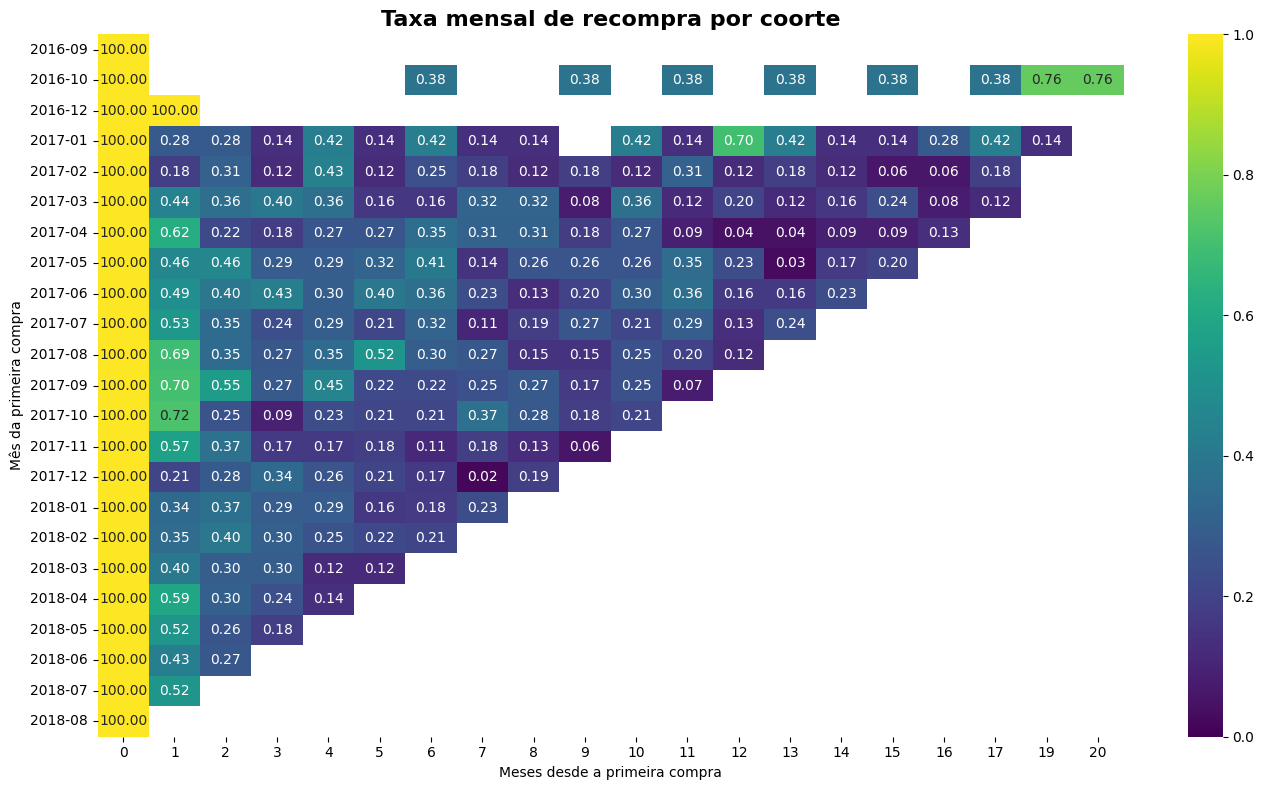

In [ ]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    retencao_coorte,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1
)

plt.title(
    "Taxa mensal de recompra por coorte",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Meses desde a primeira compra")
plt.ylabel("Mês da primeira compra")

plt.tight_layout()
plt.show()

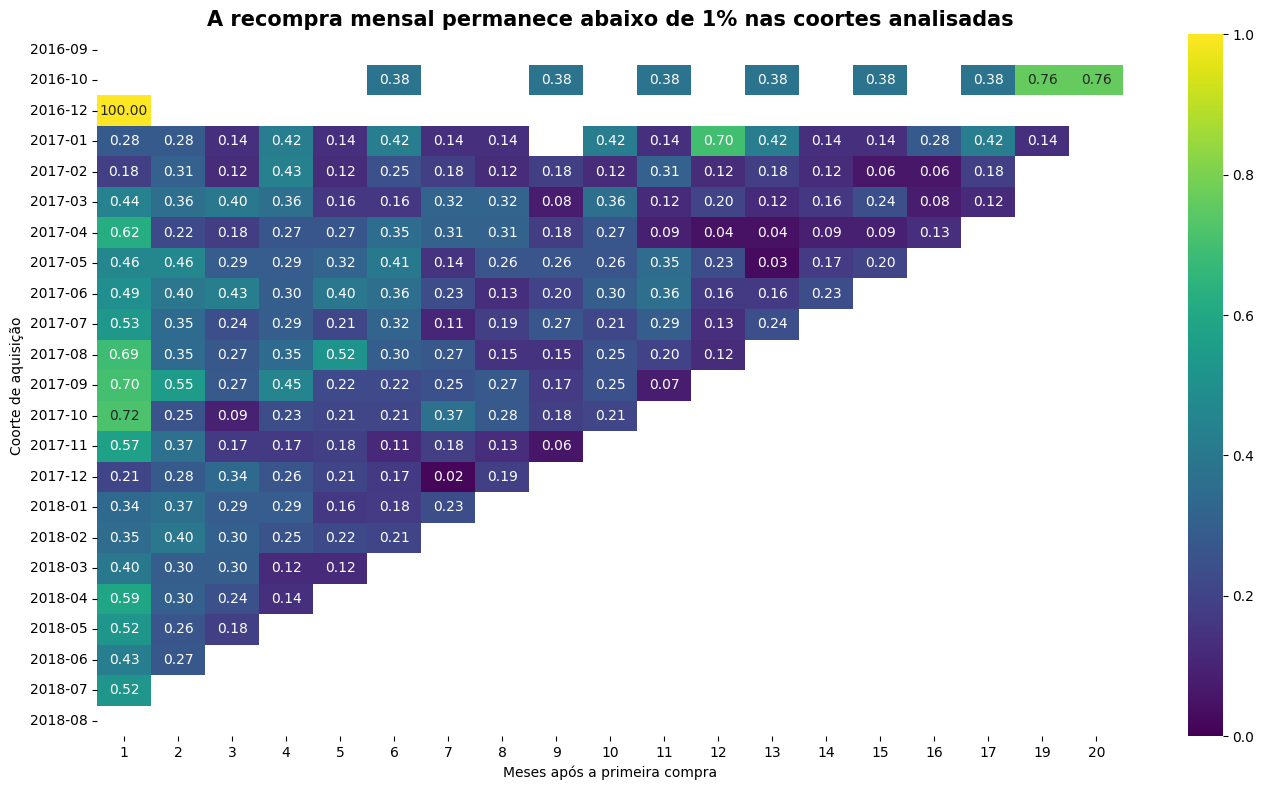

In [ ]:
retencao_visual = retencao_coorte.drop(columns=0)

plt.figure(figsize=(14, 8))

sns.heatmap(
    retencao_visual,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1
)

plt.title(
    "A recompra mensal permanece abaixo de 1% nas coortes analisadas",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Meses após a primeira compra")
plt.ylabel("Coorte de aquisição")

plt.tight_layout()
plt.show()

In [ ]:
mensal.to_csv(
    "evolucao_mensal.csv",
    index=False
)

In [ ]:
analise_estado.to_csv(
    "analise_estados.csv",
    index=False
)

In [ ]:
analise_categoria.to_csv(
    "analise_categorias.csv",
    index=False
)

In [ ]:
analise_atraso.reset_index().to_csv(
    "analise_atrasos.csv",
    index=False
)

In [ ]:
retencao_coorte.reset_index().to_csv(
    "analise_coortes.csv",
    index=False
)

In [ ]:
pedidos_reviews.to_csv(
    "base_pedidos_analitica.csv",
    index=False
)

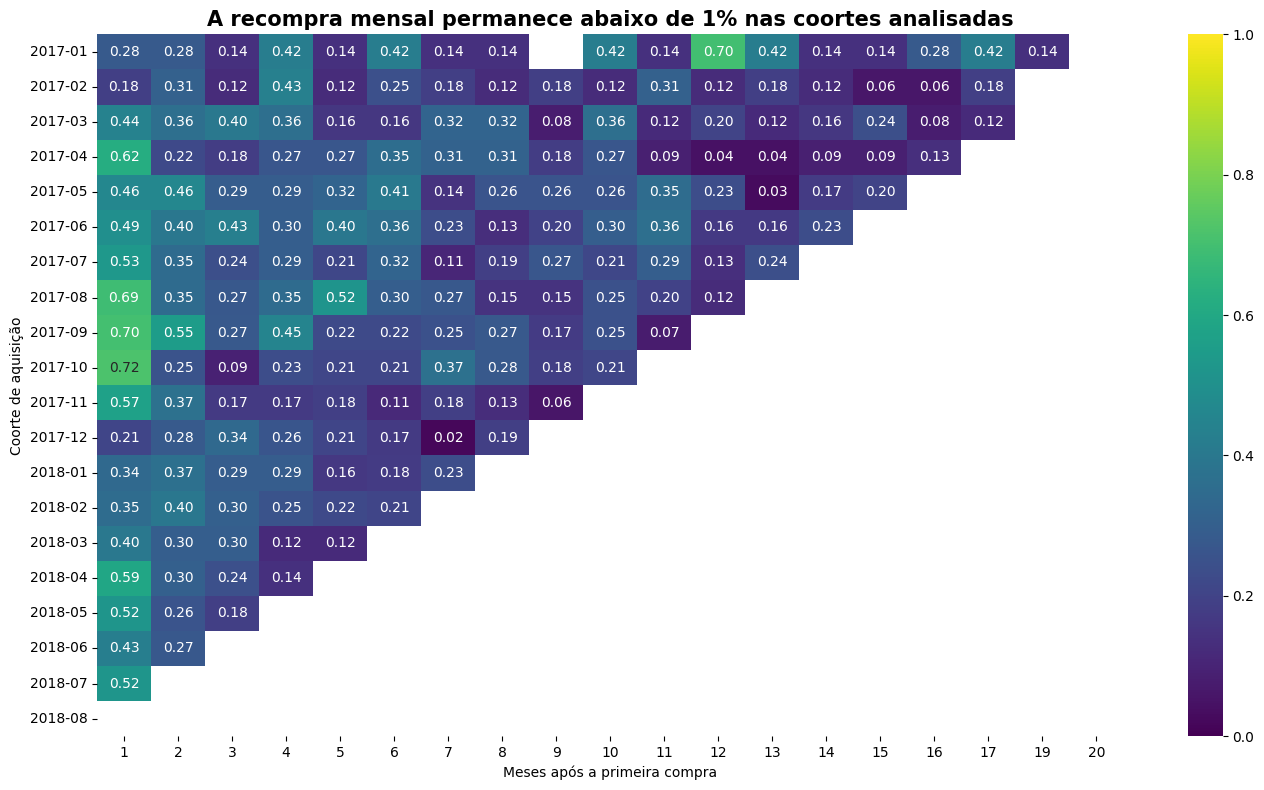

In [ ]:
retencao_visual = retencao_coorte.loc["2017-01":].drop(columns=0)

plt.figure(figsize=(14, 8))

sns.heatmap(
    retencao_visual,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1
)

plt.title(
    "A recompra mensal permanece abaixo de 1% nas coortes analisadas",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Meses após a primeira compra")
plt.ylabel("Coorte de aquisição")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# EXPORTAÇÃO DAS BASES PARA O POWER BI
# ==========================================
# 1. Evolução mensal
mensal.to_csv(
    "evolucao_mensal.csv",
    index=False
)

# 2. Análise por estado
analise_estado.to_csv(
    "analise_estados.csv",
    index=False
)

# 3. Análise por categoria
analise_categoria.to_csv(
    "analise_categorias.csv",
    index=False
)

# 4. Análise das faixas de atraso
analise_atraso.reset_index().to_csv(
    "analise_atrasos.csv",
    index=False
)

# 5. Análise de coortes
retencao_coorte.reset_index().to_csv(
    "analise_coortes.csv",
    index=False
)

# 6. Base analítica no nível de pedido
pedidos_reviews.to_csv(
    "base_pedidos_analitica.csv",
    index=False
)

print("Arquivos exportados com sucesso!")


Arquivos exportados com sucesso!


In [ ]:
# Conferência direta com a mesma lógica do Power BI

check = orders.copy()

# Datas
check["order_delivered_customer_date"] = pd.to_datetime(
    check["order_delivered_customer_date"]
)

check["order_estimated_delivery_date"] = pd.to_datetime(
    check["order_estimated_delivery_date"]
)

# Somente pedidos com status delivered
check = check[check["order_status"] == "delivered"].copy()

# Classificação exatamente como no Power BI
check["situacao_entrega"] = check.apply(
    lambda x: (
        "Atrasado"
        if x["order_delivered_customer_date"] > x["order_estimated_delivery_date"]
        else "No prazo"
    ),
    axis=1
)

print("Pedidos entregues:", check["order_id"].nunique())
print()
print(check["situacao_entrega"].value_counts())
print()
print("Percentuais:")
print(check["situacao_entrega"].value_counts(normalize=True) * 100)

Pedidos entregues: 96478

situacao_entrega
No prazo    88652
Atrasado     7826
Name: count, dtype: int64

Percentuais:
situacao_entrega
No prazo    91.888306
Atrasado     8.111694
Name: proportion, dtype: float64


In [ ]:
check_reviews = orders.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

# Converter datas
check_reviews["order_delivered_customer_date"] = pd.to_datetime(
    check_reviews["order_delivered_customer_date"],
    errors="coerce"
)

check_reviews["order_estimated_delivery_date"] = pd.to_datetime(
    check_reviews["order_estimated_delivery_date"],
    errors="coerce"
)

# Somente pedidos entregues
check_reviews = check_reviews[
    check_reviews["order_status"] == "delivered"
].copy()

# Situação da entrega
check_reviews["situacao_entrega"] = np.where(
    check_reviews["order_delivered_customer_date"] >
    check_reviews["order_estimated_delivery_date"],
    "Atrasado",
    "No prazo"
)

# Resultado
print(
    check_reviews.groupby("situacao_entrega")["review_score"]
    .agg(["count", "mean"])
)

                  count      mean
situacao_entrega                 
Atrasado           7700  2.566494
No prazo          88661  4.293737
